# Parcial 3.


In [1]:
from pylab import *
import random
from IPython.display import Image

## Integrales

In [2]:
#Trapecio
def Inte_Trap(f, a, b, N):
    h = (b-a)/N
    I = 0.5*f(a) + 0.5*f(b)
    #print(s)
    for k in range(1,N):
        I+= f(a+k*h)
    return I*h

#Simpson
def Inte_Simp(f, a, b, N):
    h=(b-a)/N
    s=0.0
    x=a + h
    for i in range(1,N,2):
        s += 4*f(x)
        x += 2*h

    x = a + 2*h
    for i in range(2,N,2):
        s += 2*f(x)
        x += 2*h
    return (h/3)*(f(a)+f(b)+s)

## Potencial de un alambre conductor

La siguiente figura muestra una alambre conductor circular de radio $a$ que lleva una corriente $i$.

El punto P está a una distancia $r$ desde el centro del alambre con coordenadas esféricas $(r, \theta, \phi)$. La componente $\phi$ del vector potencial en un punto P está dado por la siguiente integral:

$$ A_{\phi}(r,\theta) = \frac{\mu_{o}}{4\pi} \frac{4i_{o}a}{\sqrt{a^{2}+r^{2}+2ar\sin(\theta)}}\left [ \frac{(2-k^{2})K(k) - 2E(k)}{k^{2}} \right ]. $$

Donde

$$K(k)=\int_{0}^{\pi/2} \frac{d\phi}{\sqrt{1-k^{2}\sin^{2}(\phi)}}.$$

$$E(k)=\int_{0}^{\pi/2} d\phi \sqrt{1-k^{2}\sin^{2}(\phi)} .$$

$$k^{2}=\frac{4ar\sin(\theta)}{a^{2}+r^{2}+2ar\sin(\theta)}.$$

Para $a=1$, $i_{o}=3$ y $\frac{\mu_{o}}{4\pi} = 1$ grafica

**a)** $A_{\phi}(r=1.1,\theta)$ vs $\theta$, donde $\theta \in (0,2\pi]$

**b)** $A_{\phi}(r,\theta=\pi/3)$ vs $r$, donde $r \in (0, 30]$

Con ambas gráficas haz un análisis del potencial.

Image("jackson.png")

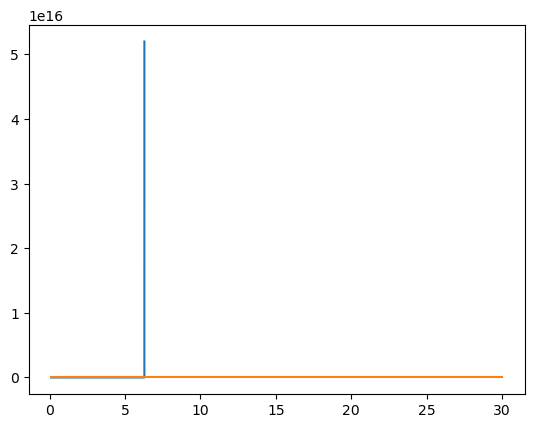

In [52]:
#Definimos la función A. Lo haremos por partes comenzando por los parámetros
a = 1
i0 = 3
Mu_0_4pi = 1

'''
Definimos la funcion potencial en phi
'''

def A_phi(r,theta):
    k2 = (4*a*r * sin(theta))/(a**2 + r**2 + 2*a*r*sin(theta))
    '''
    Primero definimos las funciones integrales que hay dentro de la función potencial phi. 
    '''
    def funcionK(phi):
        K = 1/(sqrt(1-k2*sin(phi)**2))
        return K

    def funcionE(phi):
        E = sqrt(1-k2*sin(phi)**2)
        return E
    
    A1 = Mu_0_4pi * ((4*i0*a)/(sqrt(a**2+r**2+2*a*r*sin(theta)))) #El factor fuera de los corchetes
    
    #Ahora comenzamos a construir el factor con corchetes. Aquí están las integrales.
    K = Inte_Simp(funcionK,0,pi/2,100)
    E = Inte_Simp(funcionE,0,pi/2,100)
    
    A2 = ((2-k2)*K-2*E/(k2))
    A_phi = A1*A2
    return A_phi

'''
Ya tenemos la función potencial. Comenzamos con los incisos
'''

#a) Variación en theta
theta = linspace(0.1,2*pi,10000)
r0 = 1.1

#valores1 = [A_phi(r0,th) for th in theta]
plot(theta,A_phi(r0,theta))

#B) Variación en r
r = linspace(0.1,30,100)
theta0 = pi/3
plot(r,A_phi(r,theta0))

## Ecuaciones Diferenciales Ordinarias

In [4]:
#f la ec de la EDO
#xo la condicion inicial
#a,b los extremos del intervalo
#N las interaciones

def Euler(f, a, b, xo, N):
    h=(b-a)/N
    x=[xo]
    for i in range(N-1):
        x.append(x[i]+h*f(x[i],a+h*(i+1)))
    return x

def RK2(f, a, b, xo, N):
    h=(b-a)/N
    x=[xo]
    for i in range(N-1):
        k1=h*f(x[i],a+h*(i+1))
        k2=h*f(x[i]+0.5*k1,a+h*(i+1)+0.5*h)
        x.append(x[i]+k2)
    return x

def RK4(f, a, b, xo, N):
    h=(b-a)/N
    x=[xo]
    for i in range(N-1):
        k1=h*f(x[i],a+h*(i+1))
        k2=h*f(x[i]+0.5*k1,a+h*(i+1)+0.5*h)
        k3=h*f(x[i]+0.5*k2,a+h*(i+1)+0.5*h)
        k4=h*f(x[i]+k3,a+h*(i+1)+h)
        x.append(x[i]+(k1+2*k2+2*k3+k4)/6)
    return x

#Funcion que devuelve las soluciones de una EDO de segundo orden
#f es la ecuacion diferencial
#to y tf el intervalo de tiempo donde se bucan las soluciones
#xi la condicion inicial de la solucion
#vi la condicion inicial de la derivada
#h es el tamaño de paso
#metodo, es la tecnica a utilizar
def EDO2(f, to, tf, xi, vi, h, metodo):
    lista_t = arange(to,tf,h)
    lista_x = []
    lista_v = []
    r = array([xi,vi],float)
    for t in lista_t:
        lista_x.append(r[0])
        lista_v.append(r[1])
        metodo(f,r,t,h)
    return (lista_t, lista_x, lista_v)


#Para EDO de orden 2 acopladas
#f es la ecuacion diferencial
#to y tf el intervalo de tiempo donde se bucan las soluciones
#xi  la condicion inicial de la solucion de la primera funcion
#vxi la condicion inicial de la derivada de la primera funcion
#yi  la condicion inicial de la solucion de la segunda funcion
#vyi la condicion inicial de la derivada de la segunda funcion
#h es el tamaño de paso
#metodo, es la tecnica a utilizar, de la slistadas arriba

def EDO2_acoplada(f, to, tf, xi, yi, vxi, vyi, h, metodo):
    lista_t = arange(to,tf,h)
    lista_x  = []
    lista_y  = []
    lista_vx = []
    lista_vy = []
    r = array([xi,yi,vxi,vyi],float)
    for t in lista_t:
        lista_x.append(r[0])
        lista_y.append(r[1])
        lista_vx.append(r[2])
        lista_vy.append(r[3])
        metodo(f,r,t,h)
    return (lista_t, lista_x, lista_y, lista_vx, lista_vy)

def Euler2(f,r,t,h):
    r += h * f(r,t)

def RK22(f,r,t,h):
    k1 = f(r,t)
    k2 = f(r+ 0.5*h*k1, t+0.5*h)
    r += h * k2

def RK42(f,r,t,h):
    k1 = f(r,t)
    k2 = f(r + 0.5*h*k1, t + 0.5*h)
    k3 = f(r + 0.5*h*k2, t+ 0.5*h)
    k4 = f(r + h*k3, t + h)
    r += h/6 * (k1 + 2*k2 + 2*k3 + k4)

## Péndulo con resorte
Un péndulo unido a un resorte, presenta las siguientes ecuaciones diferenciales.

$$ \ddot{L} = \left ( L_{o} + L \right )\dot{\theta}^{2} - \frac{k}{m}L + 2g\cos\left ( \theta \right ).$$
$$ \ddot{\theta} = \frac{-2}{L_{o} + L}\left [g\sin\left ( \theta \right ) + \dot{L}\dot{\theta}  \right ].$$

**a)**
Ecuentra las soluciones para $L$ y $\theta$ para un intervalo de tiempo $t_{o} = 0\,s$, $t_{f} =35\,s$ con las siguientes condiciones iniciales

* $L(t=0) = 1m $

* $\dot{L}(t=0) = 0.3 \,m/s$

* $\theta(t=0) = 0.01 \,rad$

* $\dot{\theta}(t=0) = 2 \,rad/s$


Las constantes del sistema son $g = 9.8 \,m/s^{2}$, $L_{o}=1\,m$, $m= 0.1\,kg$, $k = 4 \,N/m$;

**b)** Encuentra y analiza el espacio fase de ambas ecuaciones.

**c)** Grafica la posición X vs la posición Y del péndulo.

**d)** Recrea el experimento si el péndulo con resorte está colgado sobre el techo de un súper elevador cuando este va de subida y la gravedad disminuye a la mitad; y cuando va descendiendo y la gravedad aumenta el doble.  ¿Hay consistencia de la informacion física del sistema? Explica con tus palabras el resultado y la represetacion grafica de ello.

In [19]:
#Parámetros
g = 9.8
L0 = 1
m = 0.1
k = 4

'''
Definimos las funciones que describen a nuestras ecuaciones
'''
def derivada2L(L,theta,thdot):
    return (L0 + L)*thdot**2 - (k/m)*L + 2*g*cos(theta)

def derivada2theta(L,Ldot,theta,thdot):
    return ((-2)/(L0+L))*(g*sin(theta)+Ldot*thdot)

EDO2_acoplada(derivada2L, 0, 35, 1, 0.01, 0.3, 2, 0.01, RK42)

    

TypeError: derivada2L() missing 1 required positional argument: 'thdot'

## Presion Barometrica
La presión barométrica $p$ a una determinada altura $h$, está descrita por la siguiente ecuación diferencial.

$$ \frac{dP}{dh} = - \frac{mg}{T k_{B}}\,P.$$

Donde $m$ es  la masa de una molécula,  $g$ es el valor de la gravedad, $k_{B}$ la constante de Boltzmann, y $T$ el valor de la temperatura.

**a)**  Si la altura $h$ sobre el nivel del mar de la Ciudad de México es de 2250m, calcula la variación barométrica resolviendo la EDO con el método de tu preferencia.
Realiza en una gráfica $h$ vs $P$, donde la altura estará comprendida entre $h=0$ y $h_{max}$ Utiliza N=100 en el metodo númerico de tu preferencia.

Realiza en una gráfica $h$ vs $P$, donde la altura estará comprendida entre $h=0$ y $h_{max}$.


Repite el procedimientp si ahora la altura máxima es la del pico de Orizaba 5636m, utliza N=100.

Muestra ambas gráficas en una sola figura.

**Hint** usa escala logarítmica en ambos ejes con la instruccion `plt.xscale(´log´)`

Considera

* $P_{o} =1$
* $k_{B}=1$,
* $m=1$,
* $T = 25^{\circ}C$.

    

**b)** Interpreta y haz un análisis de la gráfica. Responde la razón de este planteamiento:

Si la altura de Ciudad de México es menor a la del pico de Orizaba, entonces la gráfica de la presión en el pico en algún momento tendria que contener la gráfica de la presion en la Ciudad de México. ¿Cuál es la razón del por qué ambas gráficas cuando se logra la altura de Ciudad de México tienen resultados diferentes?

**c)** Ahora queremos conocer como varía la presión en función de la temperatura si estamos en la altura de la Ciudad de México. Considera un intervalo de temperaturas $T = [-10^{\circ}, 40^{\circ}C]$ con 200 valores.  Para cada uno de ellos vuelve a calcular la presión final (el último valor de presión al resolver la EDO). De esta forma tendrás 200 valores de presión, uno por cada temperatura. Gráfica la temperatura vs la presión final y haz un análisis de la grafica.

**d)**  De acuerdo a la información de ambas gráficas, ¿cuál es la temperatura ideal para una persona que corre todos los días, si puede hacerlo a las 8 am donde $T= 7^{\circ}C$  ó a las 9 pm donde $25^{\circ}C$.
En la gráfica que te ayude a responder, localiza ambas temperaturas. Utiliza un marker especial para resaltarlas o un `plt.vline(posicion_ejeX, yo, yf)`.  


**NOTA** utiliza escala kelvin en las temperaturas para no tener problemas de indeterminaciones.

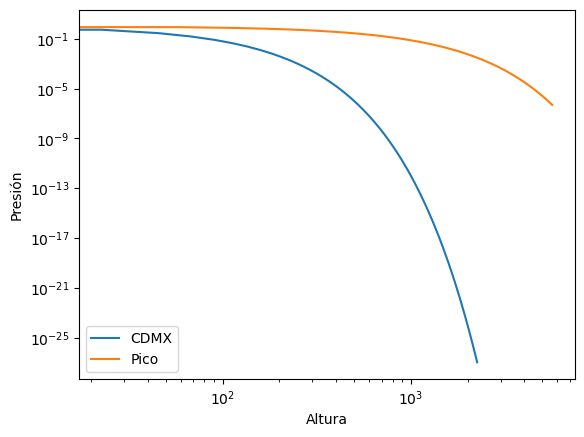

In [70]:
P0 = 1
kb = 1
m = 1
T = 298.15

def f(P,h):
    dP = -((m*g)/(T*kb))*P
    return dP

h1 = linspace(0,2250,100)
h2 = linspace(0,5636,100)
plot(h1,RK2(f, 0, 2250, 1, 100),label='CDMX')
plot(h2,RK2(f, 0, 5636, 1, 100),label='Pico')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Altura')
plt.ylabel('Presión')
plt.legend()

Text(0, 0.5, 'Presión')

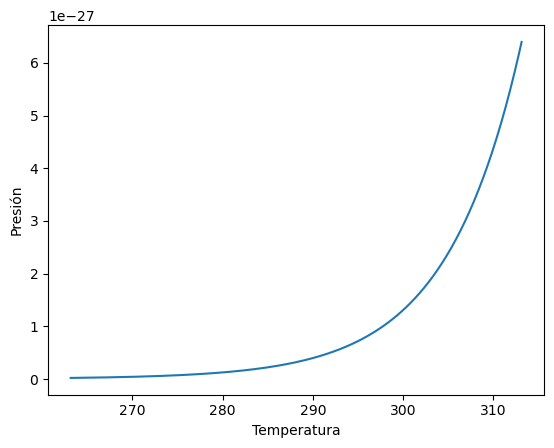

In [92]:
T = linspace(263.15,313.15,200)
lista_P = []

for i in range(200):
    def f(P,h):
        dP = -((m*g)/(T[i]*kb))*P
        return dP
    P = RK2(f,0,2250,1,100)
    pf = P[99]
    lista_P.append(pf)

plot(T,lista_P)
plt.xlabel('Temperatura')
plt.ylabel('Presión')

Vemos que conforme aumenta la temperatura la presión también aumenta, y estas crecen a la misma taza. Es importante recordar que esto sucede con el mismo valor de altura.

No pude graficar la linea vertical pero para mayor temperatura vamos a tener una mayor presión por lo que es mejor correr a las 9pm a 25 grados Celsius si lo que se busca es una carrera sencilla, sin embargo, si lo que buscas es mejorar tu resistencia será mucho mejor correr a las 8am a 7 grados Celsius ya que tendrás menor presión en el ambiente.

## Por favor explica Leapfrog con tus propias palabras.